In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from visualize_ean_plotly import plot_ean_plotly, draw_ean_plotly, show_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path
import report as rp

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways, get_scenario
from tools.RailML2trip_data.reassign_trip_id import reassign_trip_ids_by_departure
from tools.RailML2trip_data.add_side_nodes_to_trip_data import add_side_nodes_to_trip_data

# Import infrastructure and timetable, clean and prepare data

In [2]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
scenario = get_scenario()
scenario_dir = project_root / "results" / str(scenario)
scenario_dir.mkdir(parents=True, exist_ok=True)
trip_data = np.load(rf"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\tools\RailML2trip_data\trip_data_{scenario}.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [3]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [4]:
trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data)

In [5]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [6]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [7]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [8]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_ME_01', 'Dev_MAR_01'): ['Dev_ME_01', 'Pa_ME', 'SC_ME', 'Pr_ME_LT', 'Pr_E_LAG_01', 'Pa_LAG_31', 'LAG', 'Pa_LAG_32', 'Dev_LAG_02', 'Pr_E_LAG_02', 'Pr_E_MAR_01', 'Pr_I_MAR_91', 'PL04', 'Pa_E_MAR_81', 'Pr_I_MAR_71', 'PL05', 'Pa_I_MAR_61', 'Pr_I_MAR_51', 'Dev_MAR_01'], ('Dev_MAR_01', 'Dev_MAR_02'): ['Dev_MAR_01', 'Pa_I_MAR_31_side', 'MAR_side', 'Pa_I_MAR_32_side', 'Dev_MAR_02'], ('ME', 'Dev_ME_01'): ['ME', 'Dev_ME_01'], ('Dev_ORIS_01', 'Pa_ORIS_32'): ['Dev_ORIS_01', 'Pr_I_ORIS_71', 'PL30', 'Pa_ORIS_31', 'ORIS', 'Pa_ORIS_32'], ('Pa_ORIS_32', 'Dev_SPON_02'): ['Pa_ORIS_32', 'Pr_E_ORIS_02_side', 'HD_702_02_side', 'Pr_E_SPON_01_side', 'Pa_E_SPON_81_side', 'Pr_I_SPON_71_side', 'PL31_side', 'Pr_I_SPON_51_side', 'Pa_I_SPON_61_side', 'Dev_SPON_01_side', 'Pa_I_SPON_31_side', 'SPON_side', 'Pa_I_SPON_32_side', 'Dev_SPON_02'], ('ME_side', 'Dev_ME_01'): ['ME_side', 'Dev_ME_01'], ('Dev_COLD_01', 'Dev_PL24_01'): ['Dev_COLD_01', 'COLD_side', 'Pa_I_COLD_71_side', 'PL21_side', 'Pr_I_COLD_52_sid

In [9]:
# Remove opposite-direction headways on double-track chains

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [10]:
min_dwell_by_station = {
    "ME": 0,
    "LAG": 30,
    "MAR": 30,
    "TEL": 30,
    "RAB": 30,
    "PLA": 30,
    "NAT": 60,
    "STA": 60,
    "CIA": 30,
    "CAB": 30,
    "LAC": 90,
    "COLD": 30,
    "SIL": 60,
    "LASA": 60,
    "ORIS": 30,
    "SPON": 30,
    "SLU": 30,
    "MAL": 0, 
}

In [11]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)

G_scheduled = build_ean(
    trip_data_enriched,
    min_dwell_by_station=min_dwell_by_station,
)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

# Stochastic Perturbation

In [12]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=100,
    entry_delay_mean=1*60,
    entry_delay_std=3*60,
    running_delay_mean=1*60,
    running_delay_std=1*60,
    perturbation_probability = 0.05,
    seed=42,
)

## Propagation

In [13]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations,edge_perturbations,):

    G_realized = propagate(G_scheduled,edge_perturbations=edge_p,node_perturbations=node_p,)
    realized_graphs.append(G_realized)

## Visualization

### Plotly

In [14]:
fig, ax = plot_ean_plotly(G_scheduled,nodesDf,edgesDf,title=f"Scenario {scenario}: Scheduled vs Perturbed Timetable",)

for G_realized in realized_graphs[72:74]:

    draw_ean_plotly(G_realized,nodesDf,ax,alpha=0.5,linewidth_scale=0.8,)


show_ean(fig,filename=scenario_dir / f"ean_visualization{scenario}.html",auto_open=True,)

EAN visualization written to: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\results\3e\ean_visualization3e.html


WindowsPath('C:/Users/LeoC/VSCodes/optimizationVinschgau/AusbauVinschgau/results/3e/ean_visualization3e.html')

# Punctuality indicators 

Average delayed (>3 min) arrivals in a day: 132.88
Average primary delayed arrivals: 12.42
Average secondary delayed arrivals: 120.46

Secondary delayed nodes:
realization=0 node=(3, 'HD_801_07', 'arr', 33) train=3 station=HD_801_07 delay=5.19 min
realization=0 node=(3, 'SLU_side', 'arr', 34) train=3 station=SLU_side delay=5.19 min
realization=0 node=(3, 'MAL_side', 'arr', 35) train=3 station=MAL_side delay=4.61 min
realization=0 node=(4, 'Dev_PL13_01', 'arr', 7) train=4 station=Dev_PL13_01 delay=3.59 min
realization=0 node=(4, 'Pr_I_CAB_71', 'arr', 8) train=4 station=Pr_I_CAB_71 delay=3.34 min
realization=0 node=(4, 'Dev_LAC_01', 'arr', 9) train=4 station=Dev_LAC_01 delay=3.17 min
realization=0 node=(4, 'LAC_side', 'arr', 10) train=4 station=LAC_side delay=3.16 min
realization=0 node=(4, 'Dev_SIL_05', 'arr', 14) train=4 station=Dev_SIL_05 delay=3.01 min
realization=0 node=(4, 'MAL_side', 'arr', 23) train=4 station=MAL_side delay=3.51 min
realization=0 node=(6, 'HD_801_07', 'arr', 33) 

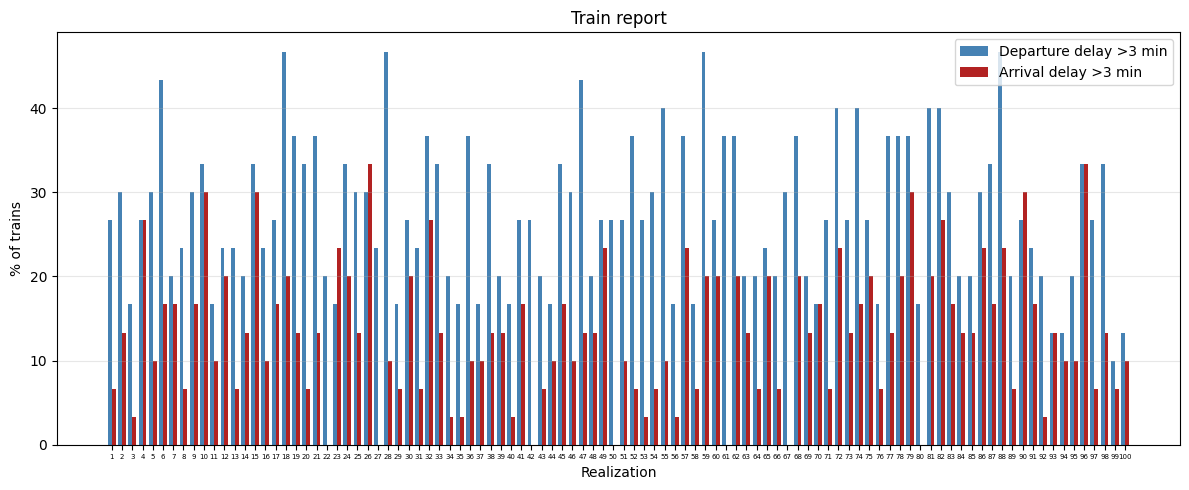

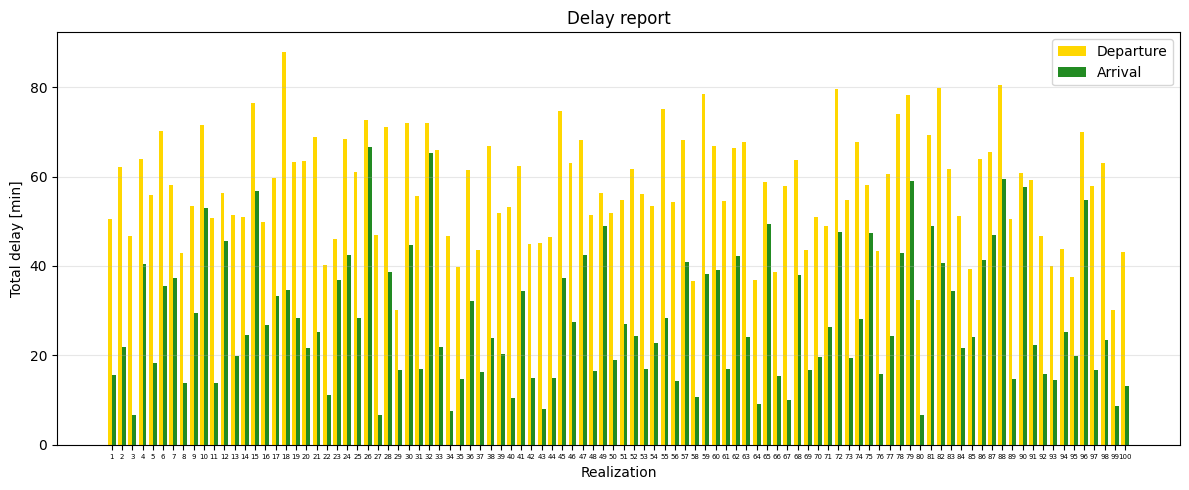

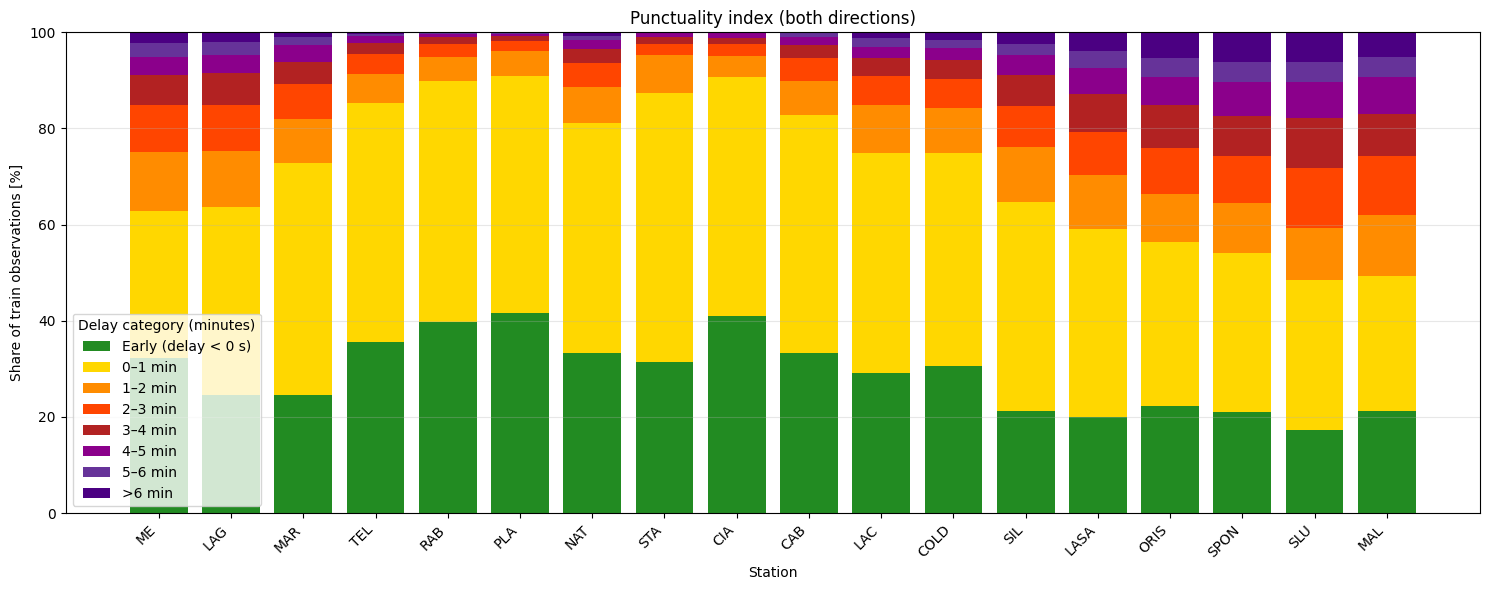

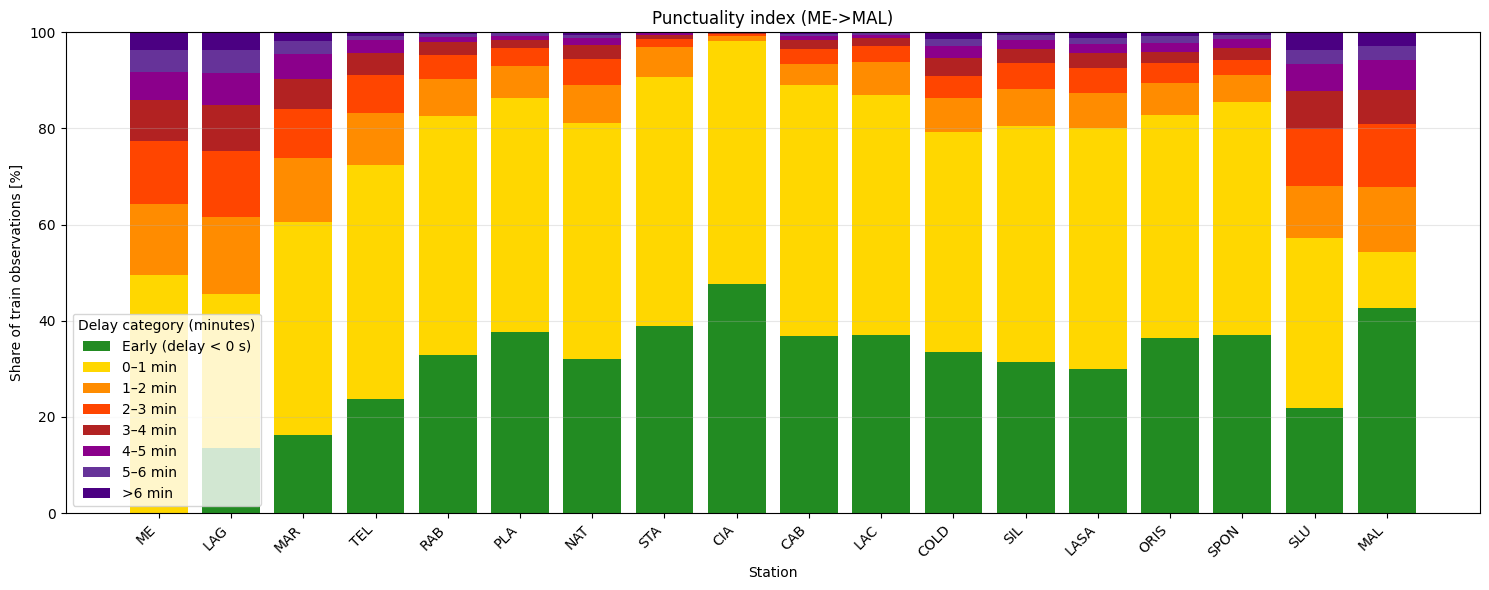

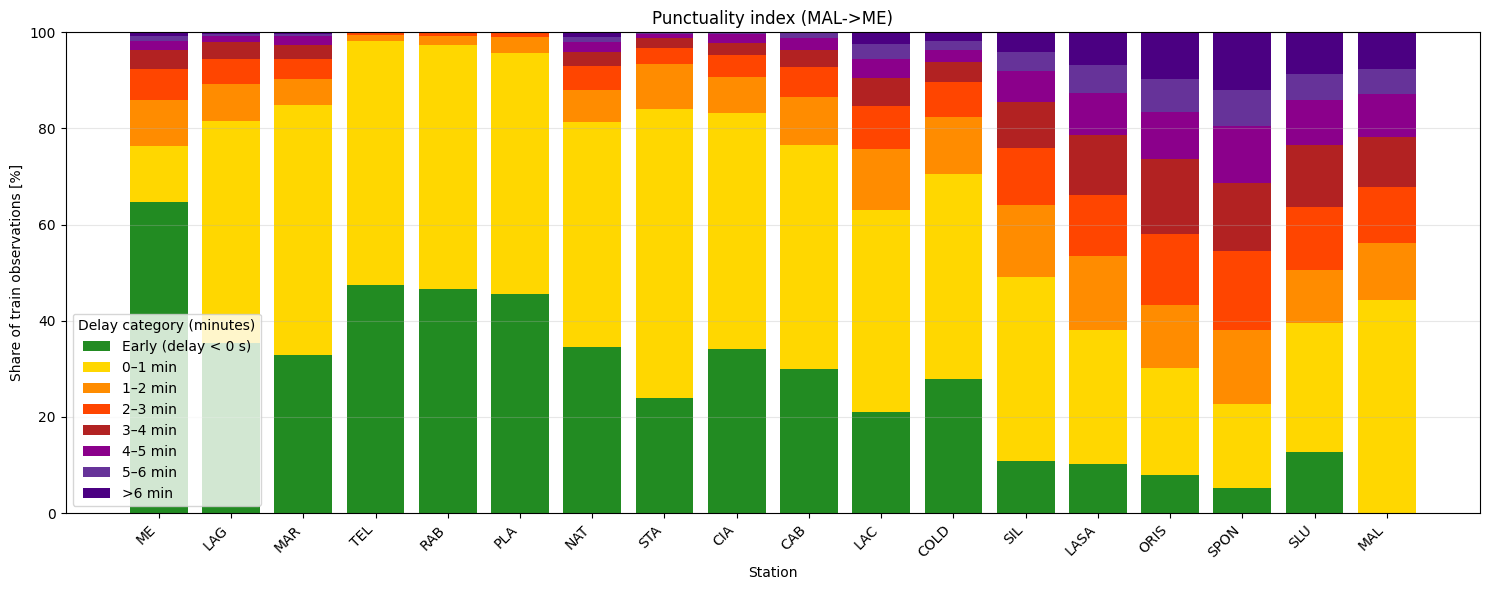

In [15]:
stats = rp.extract_statistics(realized_graphs)
delay_classification = rp.classify_arrival_delays(realized_graphs)

print(f"Average delayed (>3 min) arrivals in a day: {delay_classification['total']/len(realized_graphs)}")
print(f"Average primary delayed arrivals: {delay_classification['primary']/len(realized_graphs)}")
print(f"Average secondary delayed arrivals: {delay_classification['secondary']/len(realized_graphs)}")
print("\nSecondary delayed nodes:")
for delay in delay_classification["delays"]:
    if delay["classification"] == "secondary":
        print(
            f"realization={delay['realization']} "
            f"node={delay['node']} "
            f"train={delay['train']} "
            f"station={delay['station']} "
            f"delay={delay['delay_seconds'] / 60:.2f} min"
        )

rp.plot_train_report(stats, output_dir=scenario_dir)
rp.plot_delay_report(stats, output_dir=scenario_dir)
rp.plot_punctuality_index(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_me_to_mal(stats, output_dir=scenario_dir)
rp.plot_punctuality_index_mal_to_me(stats, output_dir=scenario_dir)

In [16]:
travel_report = rp.summarize_travel_time_report(G_scheduled, realized_graphs)
rp.print_travel_time_report(travel_report)

Scheduled timetable report
------------------------------------------------------------------------
 fast trains: scheduled 57.0 min/train (10 trains); realized avg 56.7 min
 slow trains: scheduled 83.3 min/train (20 trains); realized avg 82.0 min
------------------------------------------------------------------------


In [17]:
scheduled_graph = {}
scheduled_graph[0] = G_scheduled

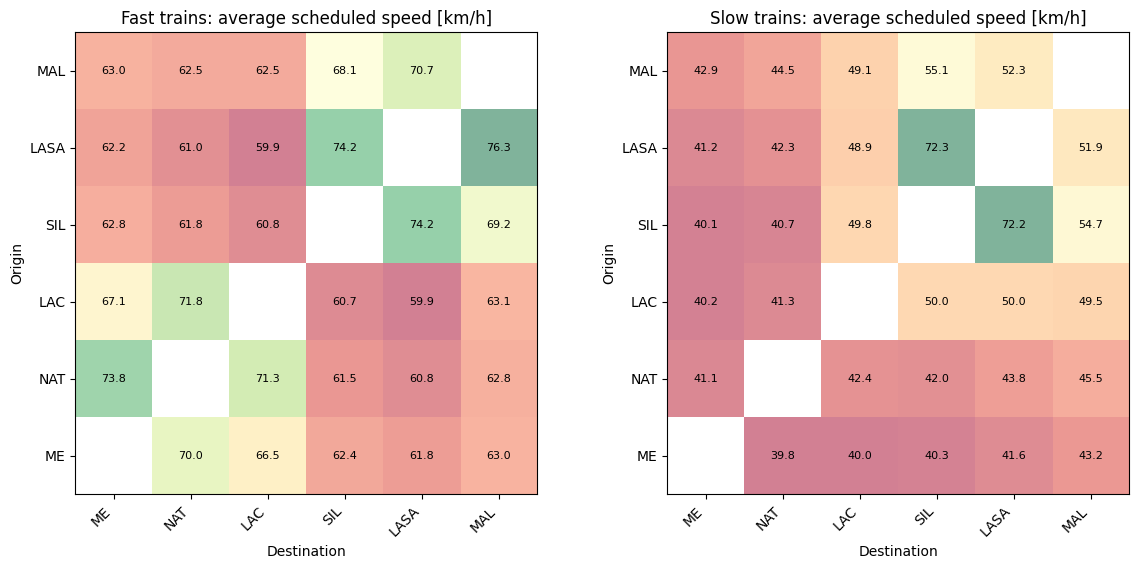

(array([[62.96633548, 62.5096248 , 62.53901193, 68.11286449, 70.72242744,
                 nan],
        [62.159447  , 60.99510404, 59.94019088, 74.17241379,         nan,
         76.25547653],
        [62.81218837, 61.75083612, 60.8150495 ,         nan, 74.17241379,
         69.18083624],
        [67.05257798, 71.7843594 ,         nan, 60.69486166, 59.87669492,
         63.14862385],
        [73.78078292,         nan, 71.30975207, 61.4937552 , 60.8090299 ,
         62.84280443],
        [        nan, 69.96310461, 66.50227273, 62.40880734, 61.82704354,
         63.04002341]]),
 array([[42.94217141, 44.52661381, 49.10501505, 55.05803301, 52.27669797,
                 nan],
        [41.16589234, 42.30553095, 48.89193975, 72.30252101,         nan,
         51.88162606],
        [40.12127612, 40.66411376, 49.81609116,         nan, 72.20153983,
         54.74024006],
        [40.20905288, 41.2650853 ,         nan, 49.97822674, 49.95458333,
         49.49941823],
        [41.07945688,       

In [18]:
rp.plot_speed_matrices([G_scheduled], nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

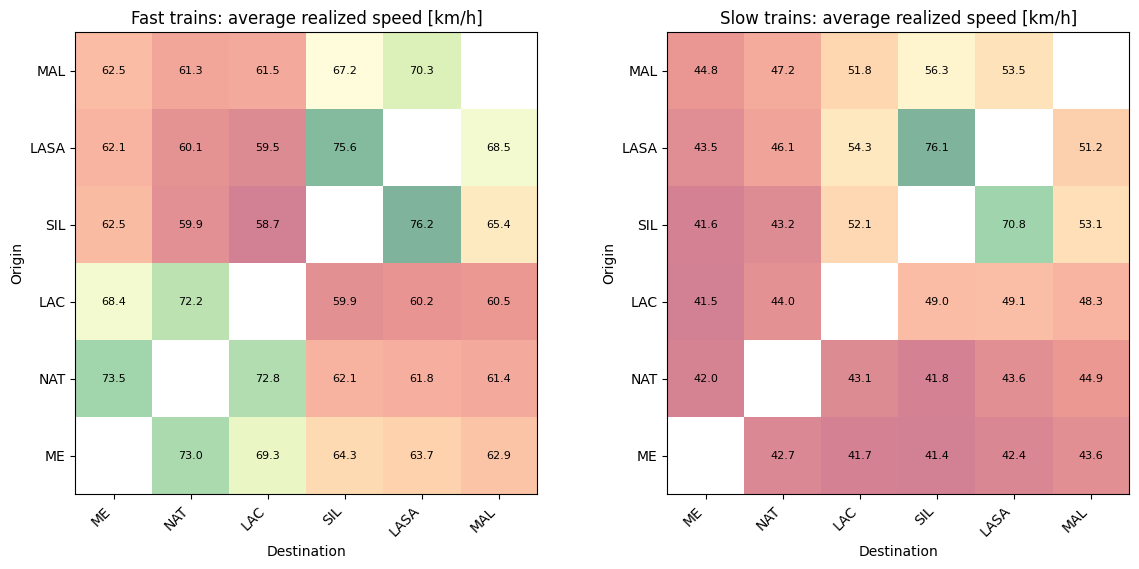

(array([[62.51454953, 61.32543842, 61.48093105, 67.16929526, 70.31844599,
                 nan],
        [62.12854253, 60.05496014, 59.51053976, 75.6370637 ,         nan,
         68.48250871],
        [62.48126695, 59.8731948 , 58.66084549,         nan, 76.24126749,
         65.38610333],
        [68.44994605, 72.15031334,         nan, 59.93467758, 60.19214594,
         60.480923  ],
        [73.52629092,         nan, 72.76726366, 62.08218214, 61.79395949,
         61.40866204],
        [        nan, 73.03266   , 69.34350514, 64.2607487 , 63.74242348,
         62.94742658]]),
 array([[44.81272995, 47.17087476, 51.79932142, 56.3213763 , 53.45801402,
                 nan],
        [43.47240979, 46.11198127, 54.29839316, 76.05224918,         nan,
         51.20871055],
        [41.63255941, 43.20692328, 52.08477593,         nan, 70.79287334,
         53.07580901],
        [41.5439031 , 43.98013923,         nan, 48.98111865, 49.09666507,
         48.26212637],
        [42.02150635,       

In [19]:
rp.plot_speed_matrices(realized_graphs, nodesDf, ("ME", "NAT", "LAC", "SIL", "LASA", "MAL"), output_dir=scenario_dir)

In [20]:
stop

NameError: name 'stop' is not defined

# Manual Perturbation

## Propagation

In [ ]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [ ]:
for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):
    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    print(f"\nScenario {i}")
    print("-" * 100)

    for train in sorted(arrival_report):
        r = arrival_report[train]

        print(
            f"Train {train:>2}: "
            f"dep_sched={format_time(r['dep_sched'])}   "
            f"dep_real={format_time(r['dep_real'])}   "
            f"arr_sched={format_time(r['arr_sched'])}   "
            f"arr_real={format_time(r['arr_real'])}   "
            f"delay={format_time(r['delay'])}"
        )

In [ ]:
u = (15, 'Dev_TEL_01', 'arr', 6) 
v = (31, 'Dev_TEL_01', 'dep', 34)
gap = float(realized_graphs[0].nodes[v]["time"]) - float(realized_graphs[0].nodes[u]["time"])

gap

In [ ]:
# Print active headway edges in realized_graphs[1]
try:
    G = realized_graphs[1]
except Exception as e:
    print("realized_graphs[1] not available in this context:", e)
else:
    active_headways = []
    for u, v, data in G.edges(data=True):
        if data.get("kind") == "headway" and data.get("is_active") is not True:
            active_headways.append((u, v, data))

    print(f"Active headway edges in realized_graphs[1]: {len(active_headways)}")
    for u, v, d in active_headways:
        print(u, v, d)
